In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


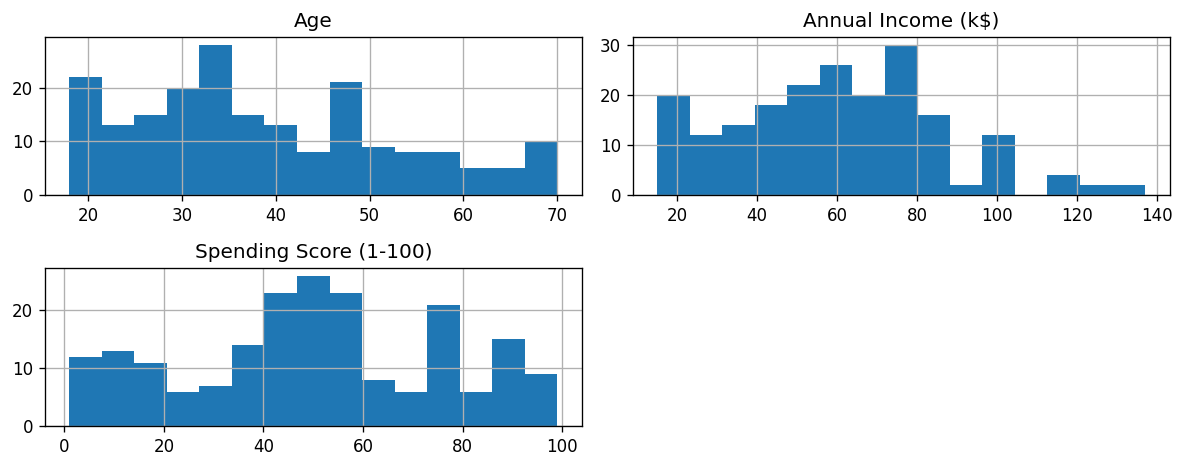

In [4]:
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 120

data_path = "../data/raw/Mall_Customers.csv"
df = pd.read_csv(data_path)

df.head()
df.info()
df.describe(include='all')

df.isna().sum()

numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
df[numeric_cols].describe()

df[numeric_cols].hist(bins=15, figsize=(10, 4))
plt.tight_layout()
plt.show()

In [5]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

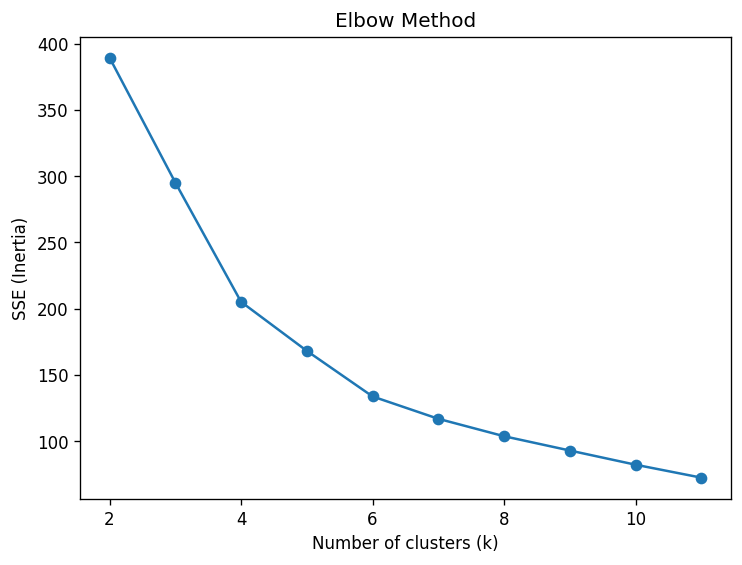

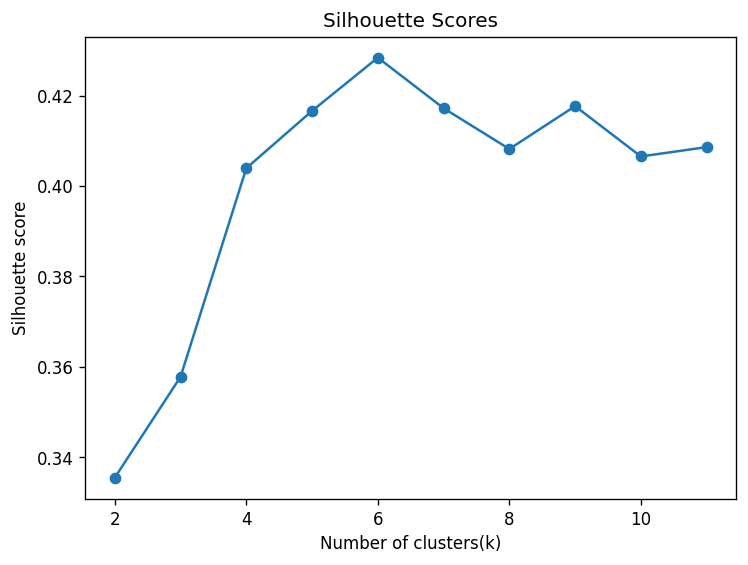

[(2, np.float64(0.33547192894004574)),
 (3, np.float64(0.357793388710272)),
 (4, np.float64(0.4039582785148566)),
 (5, np.float64(0.41664341513732767)),
 (6, np.float64(0.4284167762892592)),
 (7, np.float64(0.417231894954916)),
 (8, np.float64(0.4082067042807375)),
 (9, np.float64(0.4176925062407648)),
 (10, np.float64(0.40655411010117004)),
 (11, np.float64(0.40861878459370105))]

In [6]:
sse = []
sil_scores = []
k_values = range(2,12)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sse.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(k_values, sse, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

plt.plot(k_values, sil_scores, marker='o')
plt.xlabel('Number of clusters(k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Scores')
plt.show()

list(zip(k_values,sil_scores))

In [7]:
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
df['cluster'].value_counts()

cluster_profile = df.groupby('cluster').agg(
    count=('CustomerID', 'count'),
    avg_age=('Age', 'mean'),
    avg_income=('Annual Income (k$)', 'mean'),
    avg_spend=('Spending Score (1-100)', 'mean')
).reset_index()

cluster_profile

,cluster,count,avg_age,avg_income,avg_spend
0,0,45,56.333333,54.266667,49.066667
1,1,39,26.794872,57.102564,48.128205
2,2,33,41.939394,88.939394,16.969697
3,3,39,32.692308,86.538462,82.128205
4,4,23,25.000000,25.260870,77.608696
5,5,21,45.523810,26.285714,19.380952


In [8]:
for _, row in cluster_profile.iterrows():
    c = int(row['cluster'])
    print(f"Cluster {c}:")
    print(f"  Count           : {row['count']}")
    print(f"  Avg Age         : {row['avg_age']:.1f}")
    print(f"  Avg Income (k$) : {row['avg_income']:.1f}")
    print(f"  Avg Spend Score : {row['avg_spend']:.1f}")
    print()

Cluster 0:
  Count           : 45.0
  Avg Age         : 56.3
  Avg Income (k$) : 54.3
  Avg Spend Score : 49.1

Cluster 1:
  Count           : 39.0
  Avg Age         : 26.8
  Avg Income (k$) : 57.1
  Avg Spend Score : 48.1

Cluster 2:
  Count           : 33.0
  Avg Age         : 41.9
  Avg Income (k$) : 88.9
  Avg Spend Score : 17.0

Cluster 3:
  Count           : 39.0
  Avg Age         : 32.7
  Avg Income (k$) : 86.5
  Avg Spend Score : 82.1

Cluster 4:
  Count           : 23.0
  Avg Age         : 25.0
  Avg Income (k$) : 25.3
  Avg Spend Score : 77.6

Cluster 5:
  Count           : 21.0
  Avg Age         : 45.5
  Avg Income (k$) : 26.3
  Avg Spend Score : 19.4



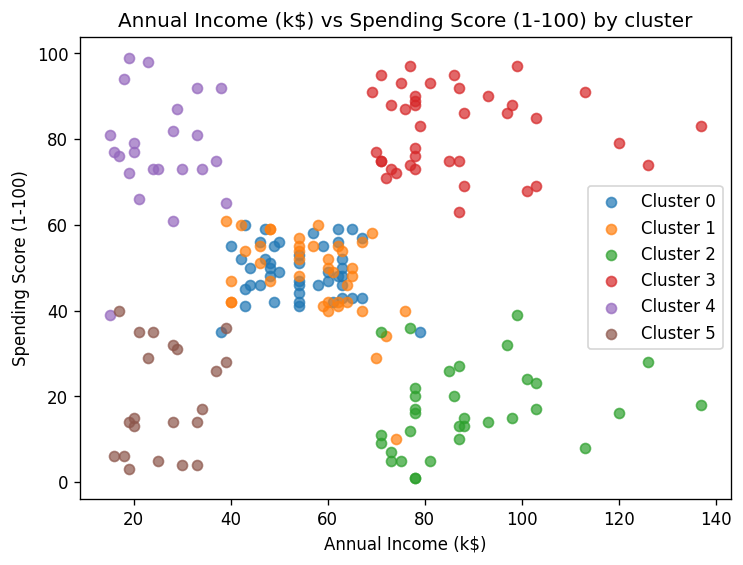

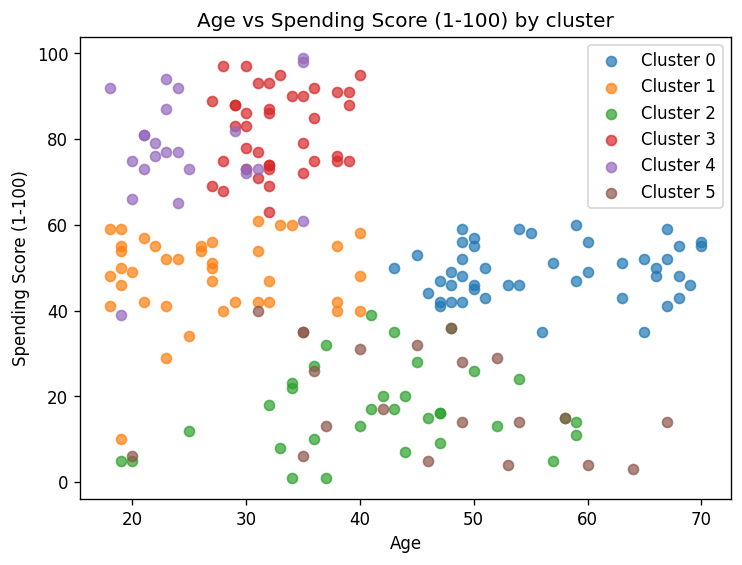

In [9]:
for x_col, y_col in [
    ('Annual Income (k$)', 'Spending Score (1-100)'),
    ('Age', 'Spending Score (1-100)')
]:
    plt.figure()
    for c in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == c]
        plt.scatter(subset[x_col], subset[y_col], alpha=0.7, label= f'Cluster {c}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'{x_col} vs {y_col} by cluster')
    plt.legend()
    plt.show()